## 10.2. Attention Pooling: Nadaraya-Watson Kernal Regression

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

### 10.2.1 Dataset Generation

$$
y_i = 2\sin(x_i) + x_i^{0.8} + ϵ
$$

In [2]:
n_train = 50 # training sample num
x_train, _ = torch.sort(torch.rand(n_train) * 5) # training sample after sorting

def f(x):
  return 2 * torch.sin(x) + x * 0.8

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,)) # train sample output
x_test = torch.arange(0, 5, 0.1) # test sample
y_truth = f(x_test) # real output of test sample
n_test = len(x_test) # test sample num
n_test

50

In [3]:
def plot_kernel_reg(y_hat):
  d2l.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'])
  d2l.plt.plot(x_train, y_train, 'o', alpha=0.5);

### 10.2.2 Average Pooling

$$
f(x) = \frac1n\sum_{i=1}^ny_i
$$

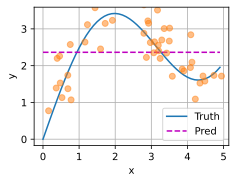

In [4]:
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

### 10.2.3 Non-Parametric Attention Pooling

$$
f(x) = \sum_{i=1}^n\frac{K(x - x_i)}{\sum_{j=1}^nK(x - x_j)}y_i
$$

$$
f(x) = \sum_{i=1}^n\alpha(x, x_i)y_i
$$

$$
K(u) = \frac1{\sqrt{2π}}\exp(-\frac{u^2}2)
$$

$$
\begin{aligned}
f(x)  &= \sum_{i=1}^n α(x, x_i) y_i \\ 
      &= \sum_{i=1}^n \frac{\exp(-\frac12(x - x_i)^2)}{\sum_{j=1}^n\exp(-\frac12(x - x_j)^2)}y_i \\ 
      &= \sum_{i=1}^n\text{softmax}(-\frac12(x - x_i)^2)y_i
\end{aligned}
$$

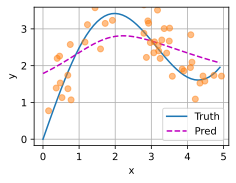

In [5]:
# X_repeat shape: (n_test, n_train)
# every line has the same test input (e.g. the sam inqury)
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
# X_train has key. attention_weights shape: (n_test, n_train)
# every line has an attention weight distributed under diff given query value (y_train)
attention_weights = nn.functional.softmax(-(X_repeat - x_train) ** 2 / 2, dim=1)
# each elem in `y_hat` is the weighted avg of value, weights are attention weight
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)  

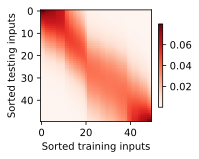

In [6]:
d2l.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')

### 10.2.4 Parametric Attention Pooling

$$
\begin{aligned}
f(x)  &= \sum_{i=1}^nα(x, x_i)y_i \\ 
      &= \sum_{i=1}^n\frac{\exp(-\frac12((x - x_i)w)^2)}{\sum_{j=1}^n\exp(-\frac12((x - x_j)w)^2)}y_i \\ 
      &= \sum_{i=1}^n\text{softmax}(-\frac12((x - x_i)w)^2)y_i
\end{aligned}
$$

#### 10.2.4.1 Batched Matrix Multiplication

In [7]:
X = torch.ones((2, 1, 4))
Y = torch.ones((2, 4, 6))
torch.bmm(X, Y).shape

torch.Size([2, 1, 6])

In [8]:
weights = torch.ones((2, 10)) * 0.1
values = torch.arange(20.0).reshape((2, 10))
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1))

tensor([[[ 4.5000]],

        [[14.5000]]])

#### 10.2.4.2 Define Model

In [9]:
class NWKernelRegression(nn.Module):
  def __init__(self, **kwargs):
    super().__init__(**kwargs)
    self.w = nn.Parameter(torch.rand((1,), requires_grad=True))
    
  def forward(self, queries, keys, values):
    # `queries` and `attention_weights` has shape(query_num, 'key-value' pair num)
    queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
    self.attention_weights = nn.functional.softmax(
      -((queries - keys) * self.w) ** 2 / 2, dim=1
    )
    # `values` shape (query_num, 'key-vale' pair num)
    return torch.bmm( self.attention_weights.unsqueeze(1),
                      values.unsqueeze(-1)).reshape(-1)

In [10]:
# `X_tile` shape: (n_train, n_train), each line has the same training input
X_tile = x_train.repeat((n_train, 1))
# Y_tile shape: (n_train, n_train), each line has the same training input
Y_tile = y_train.repeat((n_train, 1))
# key shape: ('n_train', 'n_train' - 1)
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
# values shape: ('n_train', 'n_train'-1)
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))

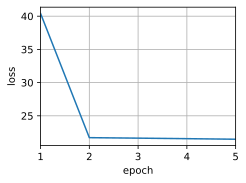

In [11]:
net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[1, 5])

for epoch in range(5):
  trainer.zero_grad()
  l = loss(net(x_train, keys, values), y_train)
  l.sum().backward()
  trainer.step()
  print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
  animator.add(epoch + 1, float(l.sum()))

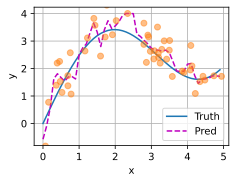

In [12]:
# keys shape: (n_test, n_train), each line has the same training input (e.g. the same key)
keys = x_train.repeat((n_test, 1))
# value shape: (n_test, n_train)
values = y_train.repeat((n_test, 1))
y_hat = net(x_test, keys, values).unsqueeze(1).detach()
plot_kernel_reg(y_hat)

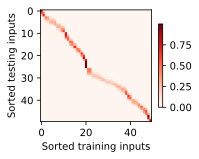

In [14]:
d2l.show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')